<a href="https://colab.research.google.com/github/besturkmen/AcademiQ_Data_Science/blob/main/AcademiQ_Data_Science_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ucimlrepo -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

In [4]:
wholesale_customers = fetch_ucirepo(id=292)

X= wholesale_customers.data.features.copy()

print("Dataset Boyutları:", X.shape)

display(X.head())

Dataset Boyutları: (440, 7)


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


In [5]:


display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[ 1.44865163  0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873
  -0.06633906]
 [ 1.44865163 -0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684
   0.08915105]
 [ 1.44865163 -0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164
   2.24329255]
 [-0.69029709  0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822
   0.09341105]
 [ 1.44865163  0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782
   1.29934689]]


# Elbow Method



In [7]:
inertia_values = []
cluster_range = range(1,11)

for k in cluster_range:
  model =KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10
  )
  model.fit(X_scaled)
  inertia_values.append(model.inertia_)


inertia_values = []: Bu satır, her bir küme sayısı için hesaplanacak inertia değerlerini depolamak üzere boş bir liste oluşturur. Inertia, bir küme içindeki noktaların küme merkezine olan uzaklıklarının karelerinin toplamıdır. Daha düşük inertia değeri, daha yoğun kümelenmiş kümeler anlamına gelir.

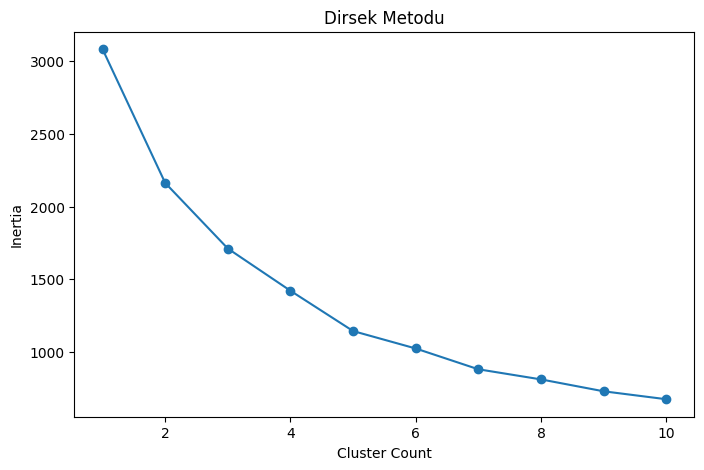

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    inertia_values,
    marker='o',

)
plt.title('Dirsek Metodu')
plt.xlabel('Cluster Count')
plt.ylabel('Inertia')
plt.show()

In [9]:
kmeans_pipeline = Pipeline(steps = [
    (
        "kmeans",
        KMeans(
            n_clusters=4,
            random_state=42,
            n_init=10
        )
    )
])
kmeans_pipeline.fit(X_scaled)

Pipeline(steps=[('kmeans', KMeans(n_clusters=4, n_init=10, random_state=42))])

In [10]:
clusters= kmeans_pipeline.predict(X_scaled)
X_clustered= X.copy()
X_clustered["cluster"]= clusters

display(X_clustered.head())

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,12669,9656,7561,214,2674,1338,0
1,2,7057,9810,9568,1762,3293,1776,0
2,2,6353,8808,7684,2405,3516,7844,0
3,1,13265,1196,4221,6404,507,1788,1
4,2,22615,5410,7198,3915,1777,5185,0


In [11]:
score= silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(score,4))

Silhouette Score: 0.4425


Score

- 0.70+ ----------------- Çok güçlü ayrışma
- 0.50 - 0.70  ---------- Güçlü
- 0.25 - 0.50  ---------- Orta / Kabul edilebilir ayrışma
- < 0.25  --------------- Zayıf ayrışma

#PCA

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca= pca.fit_transform(X_scaled)

print(X_pca[:5])

[[ 0.82904097 -0.5430644 ]
 [ 1.04816682 -0.51065187]
 [ 1.25361312  0.65630439]
 [-1.0717588   0.58525366]
 [ 0.61781187  0.94643547]]


In [14]:
print("Orijinal Boyut:", X_scaled.shape)
print("PCA Boyutları:", X_pca.shape)
print("PCA ile dönüştürülmüş verilerin ilk 5 satırı:")
display(pd.DataFrame(X_pca[:5], columns=["PC1", "PC2"]))

Orijinal Boyut: (440, 7)
PCA Boyutları: (440, 2)
PCA ile dönüştürülmüş verilerin ilk 5 satırı:


,PC1,PC2
0,0.829041,-0.543064
1,1.048167,-0.510652
2,1.253613,0.656304
3,-1.071759,0.585254
4,0.617812,0.946435


#Görselleştirme

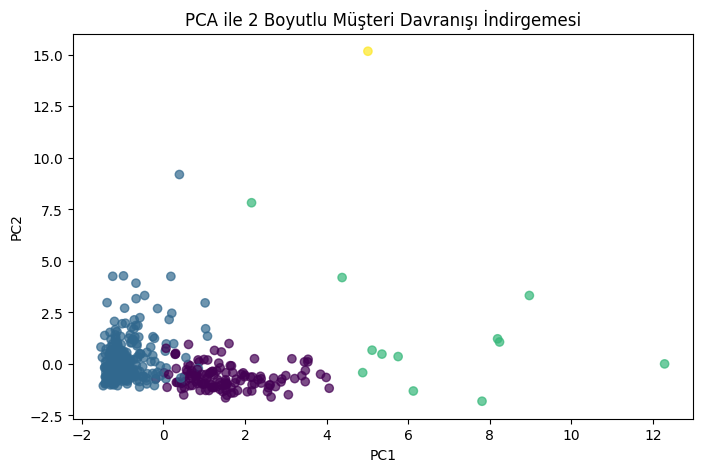

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    alpha=0.7,

)
plt.title("PCA ile 2 Boyutlu Müşteri Davranışı İndirgemesi")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#PCA Verisi Üzerinde Dirsek Metodu ile Optimal Küme Sayısı Belirleme

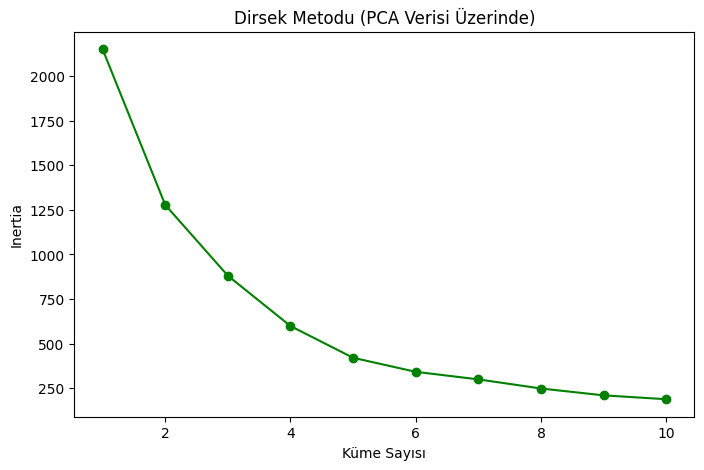

In [22]:
inertia_values_pca = []
cluster_range_pca = range(1, 11)


for k in cluster_range_pca:
    model_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
    model_pca.fit(X_pca)
    inertia_values_pca.append(model_pca.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range_pca, inertia_values_pca, marker='o', linestyle='-', color='g')
plt.title('Dirsek Metodu (PCA Verisi Üzerinde)')
plt.xlabel('Küme Sayısı')
plt.ylabel('Inertia')
plt.show()